In [1]:
from pathlib import Path

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import xclimate as xclim

In [ ]:
cluster_client = xclim.create_dask_cluster(
    account='UWAS0155',
    nworkers=4,
    ncores=1,
    nmem='16GB',
    walltime='01:00:00',
)

account:  UWAS0155
nworkers: 4
ncores:   1
nmemory:  16GB
walltime: 01:00:00


2026-03-07 10:36:14,366 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='localhost:8787', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/tornado/web.py", line 3388, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for 

{'PBSCluster-1': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-0': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-3': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-2': <dask_jobqueue.pbs.PBSJob: status=running>}

To view the dask dashboard
Run the following command in your local terminal:
> ssh -N -L 8787:128.117.211.160:8787 bbuchovecky@casper.hpc.ucar.edu
Open the following link in your local browser:
> http://localhost:8787/status


2026-03-07 10:36:18,585 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='localhost:8787', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/tornado/web.py", line 3388, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for 

In [ ]:
# xclim.close_dask_cluster(cluster_client)

In [21]:
from matplotlib.colors import LinearSegmentedColormap

brbg = plt.get_cmap("BrBG", 256)
colors = brbg(np.linspace(0, 1, 256))

center = 128
half_width = 12
lo, hi = center - half_width, center + half_width + 1

white = np.array([1.0, 1.0, 1.0, 1.0])

# left side: color -> white
t_left = np.linspace(0, 1, center - lo + 1)
colors[lo:center+1] = colors[lo:center+1] * (1 - t_left[:, None]) + white * t_left[:, None]

# right side: white -> color
t_right = np.linspace(1, 0, hi - center)
colors[center:hi] = colors[center:hi] * (1 - t_right[:, None]) + white * t_right[:, None]

cmap = LinearSegmentedColormap.from_list("BrBG_white_center_smooth", colors)

# FHIST

In [22]:
## FHIST PPE

variables = [
    "EFLX_LH_TOT_month_1",
    # "TLAI_month_1",
]

time_slice = slice("1950-01", "2014-12")
year_start = time_slice.start[:4]
year_end = time_slice.stop[:4]
grid = xclim.load_fhist_ppe_grid()

snow_pct_threshold = 100    # maximum allowable percent of snow cover on all months of the average year
nonglc_pct_threshold = 100  # maximum allowable percent of glaciated land for a NON-glaciated gridcell

fsno = xclim.load_fhist("FSNO_month_1", keep_var_only=True)["FSNO"].sel(time=time_slice).reindex_like(grid, method="nearest", tolerance=1e-3)
fsno_clim_min = fsno.groupby("time.month").mean().min(dim="month")

# Create masks
nonglc_mask = grid.PCT_GLC <= nonglc_pct_threshold
snow_mask = fsno_clim_min <= (snow_pct_threshold / 100)
full_mask = snow_mask & nonglc_mask
full_mask = nonglc_mask

fhist = {}
fhist_full = {}
for v in variables:
    print(f"  {v}")
    name = "_".join(v.split("_")[:-2])
    fhist_full[v] = xclim.load_fhist(v, keep_var_only=True)[name].sel(time=time_slice).reindex_like(grid, method="nearest", tolerance=1e-3)
    fhist_full[v] = fhist_full[v].where(full_mask)
    fhist_full[v].attrs["masks"] = f"gridcell percent glaciated land <= {nonglc_pct_threshold}"

    fhist[v] = fhist_full[v].chunk({'time': -1})

  EFLX_LH_TOT_month_1


In [23]:
et_gm_ts = fhist['EFLX_LH_TOT_month_1'].weighted(grid.LANDAREA).mean(dim=['lat', 'lon'])

et_gm_sc = et_gm_ts.groupby('time.month').mean()
et_gm_dsc = et_gm_ts.groupby('time.month') - et_gm_sc

et_gm_ta = et_gm_ts.mean(dim='time')
et_gm_yr = et_gm_ts.groupby('time.year').mean() - et_gm_ta

et_gm_dsc['time'] = et_gm_dsc.time.dt.year + (et_gm_dsc.time.dt.dayofyear - 1) / 365.25

et_gm_yr = et_gm_yr.chunk({'year': -1})
et_gm_dsc = et_gm_dsc.chunk({'time': -1})

In [24]:
et_gm_dsc_ols = xclim.regression.ols_field(et_gm_dsc.time, et_gm_dsc, sample_dim='time', alpha=0.05).compute()
et_gm_yr_ols = xclim.regression.ols_field(et_gm_yr.year, et_gm_yr, sample_dim='year', alpha=0.05).compute()

In [25]:
et_gm_dsc_1990_ols = xclim.regression.ols_field(et_gm_dsc.time.sel(time=slice('1990-01', None)), et_gm_dsc.sel(time=slice('1990-01', None)), sample_dim='time', alpha=0.05).compute()
et_gm_yr_1990_ols = xclim.regression.ols_field(et_gm_yr.year.sel(year=slice(1990, None)), et_gm_yr.sel(year=slice(1990, None)), sample_dim='year', alpha=0.05).compute()

In [7]:
et_ts = fhist['EFLX_LH_TOT_month_1']

et_sc = et_ts.groupby('time.month').mean()
et_dsc = et_ts.groupby('time.month') - et_sc

et_ta = et_ts.mean(dim='time')
et_yr = et_ts.groupby('time.year').mean() - et_ta

et_dsc['time'] = et_dsc.time.dt.year + (et_dsc.time.dt.dayofyear - 1) / 365.25

In [8]:
et_dsc_ols = xclim.regression.ols_field(et_dsc.time, et_dsc, sample_dim='time', alpha=0.05)
et_yr_ols = xclim.regression.ols_field(et_yr.year, et_yr, sample_dim='year', alpha=0.05)

In [9]:
et_dsc_1990_ols = xclim.regression.ols_field(et_dsc.time.sel(time=slice('1990-01', None)), et_dsc.sel(time=slice('1990-01', None)), sample_dim='time', alpha=0.05)
et_yr_1990_ols = xclim.regression.ols_field(et_yr.year.sel(year=slice(1990, None)), et_yr.sel(year=slice(1990, None)), sample_dim='year', alpha=0.05)

In [10]:
et_gc_mn = fhist['EFLX_LH_TOT_month_1'].mean(dim='time')
et_dsc_pct_per_yr_masked = (et_dsc_ols.slope_fdr_masked / et_gc_mn) * 100
et_dsc_pct_per_yr = (et_dsc_ols.slope / et_gc_mn) * 100

et_gc_mn = fhist['EFLX_LH_TOT_month_1'].sel(time=slice('1990-01', None)).mean(dim='time')
et_dsc_1990_pct_per_yr_masked = (et_dsc_1990_ols.slope_fdr_masked / et_gc_mn) * 100
et_dsc_1990_pct_per_yr = (et_dsc_1990_ols.slope / et_gc_mn) * 100

## trend distributions and maps

In [ ]:
# Extract slopes and land area
slopes = et_dsc_ols.slope_fdr_masked.where(grid.PCT_GLC <= 80).stack(gridcell=['lat', 'lon'])
land_area = grid.LANDAREA.where(grid.PCT_GLC <= 80).stack(gridcell=['lat', 'lon'])

# Normalize land area to fraction
total_area = land_area.sum('gridcell')
area_fraction = land_area / total_area

ncols = 6
nrows = 5

fig, axs = plt.subplots(ncols=ncols, nrows=nrows, sharex=True, sharey=True, figsize=(16, 12), layout="constrained", dpi=100)
ax = axs.flatten()

for i, m in enumerate(slopes.member.values):
    snan = slopes.sel(member=m).values
    snan[snan > 2.5] = np.nan
    snan[snan < -2.5] = np.nan
    s = snan[~np.isnan(snan)]
    w = area_fraction.values[~np.isnan(snan)]
    ax[i].hist(s, bins=100, weights=w, alpha=0.5, label=xclim.ppe.get_member_name(m));

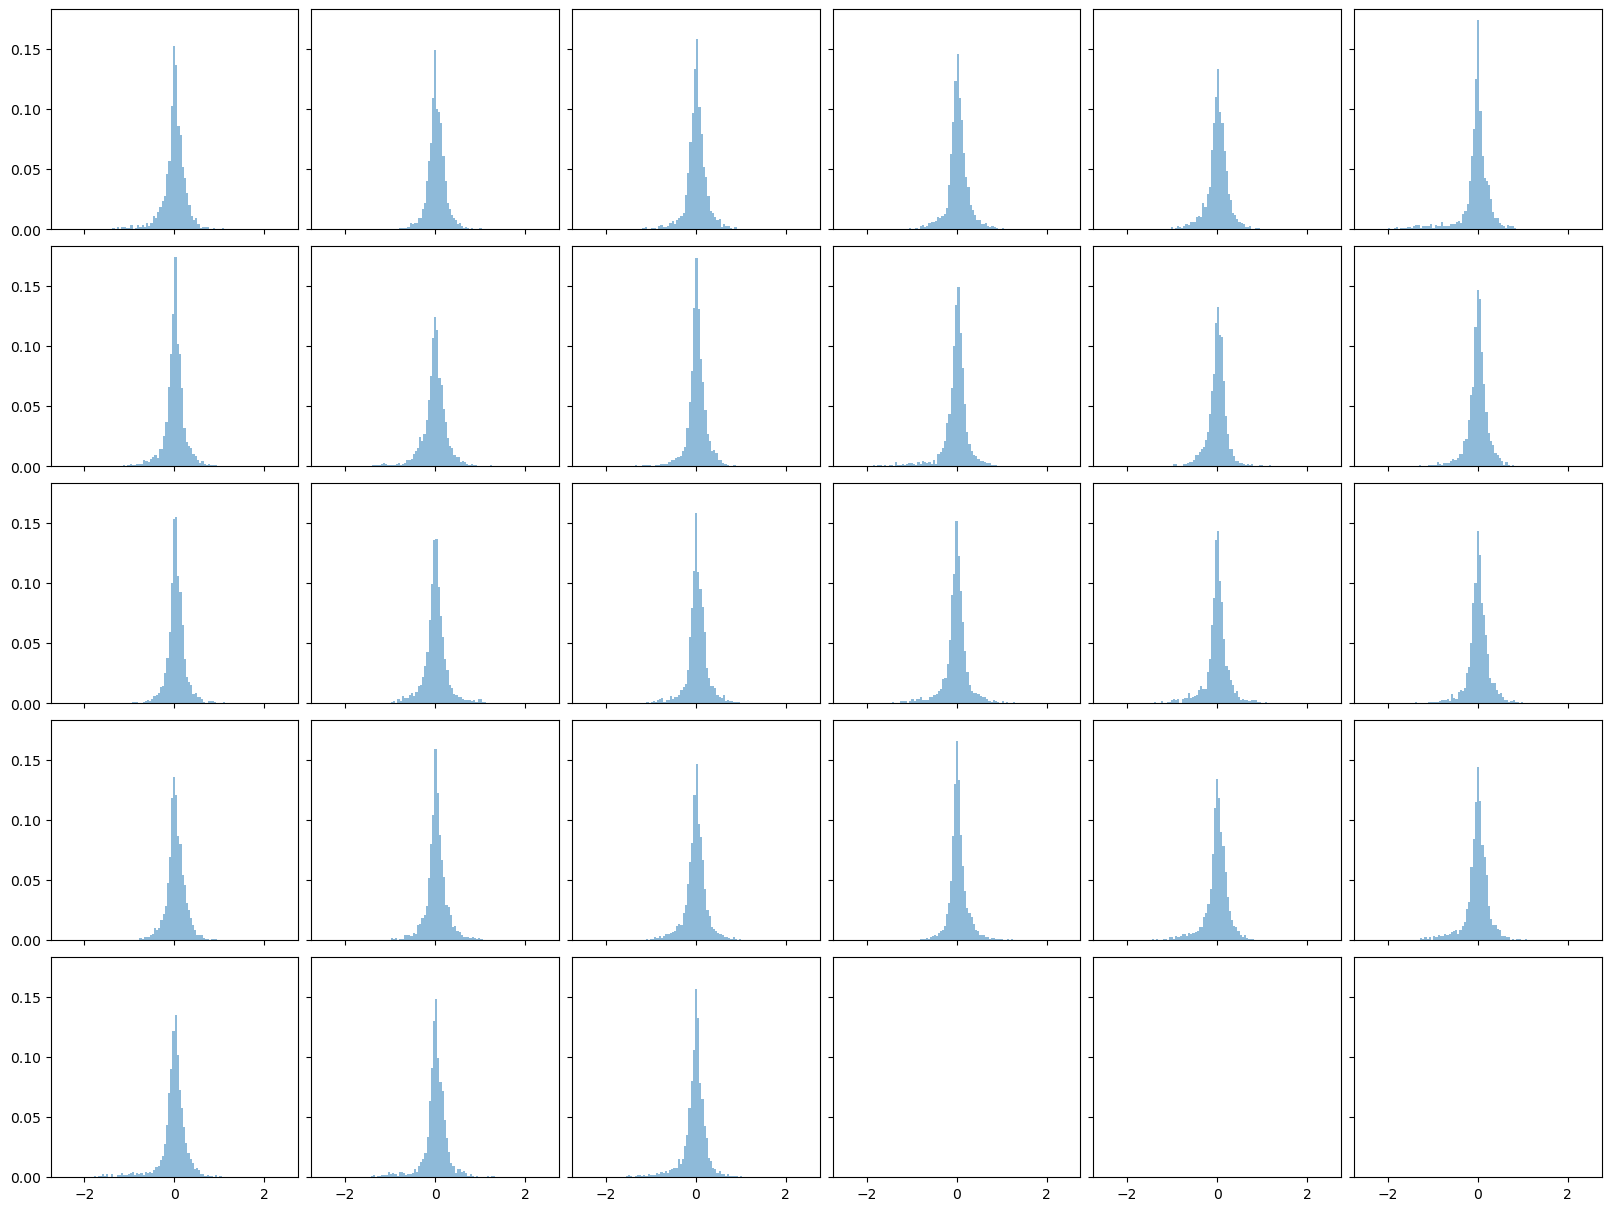

In [ ]:
# Extract slopes and land area
slopes = et_dsc_pct_per_yr.where(grid.PCT_GLC <= 80).stack(gridcell=['lat', 'lon'])
land_area = grid.LANDAREA.where(grid.PCT_GLC <= 80).stack(gridcell=['lat', 'lon'])

# Normalize land area to fraction
total_area = land_area.sum('gridcell')
area_fraction = land_area / total_area

ncols = 6
nrows = 5

fig, axs = plt.subplots(ncols=ncols, nrows=nrows, sharex=True, sharey=True, figsize=(16, 12), layout="constrained", dpi=100)
ax = axs.flatten()

for i, m in enumerate(slopes.member.values):
    snan = slopes.sel(member=m).values
    snan[snan > 2.5] = np.nan
    snan[snan < -2.5] = np.nan
    s = snan[~np.isnan(snan)]
    w = area_fraction.values[~np.isnan(snan)]
    ax[i].hist(s, bins=100, weights=w, alpha=0.5, label=xclim.ppe.get_member_name(m));

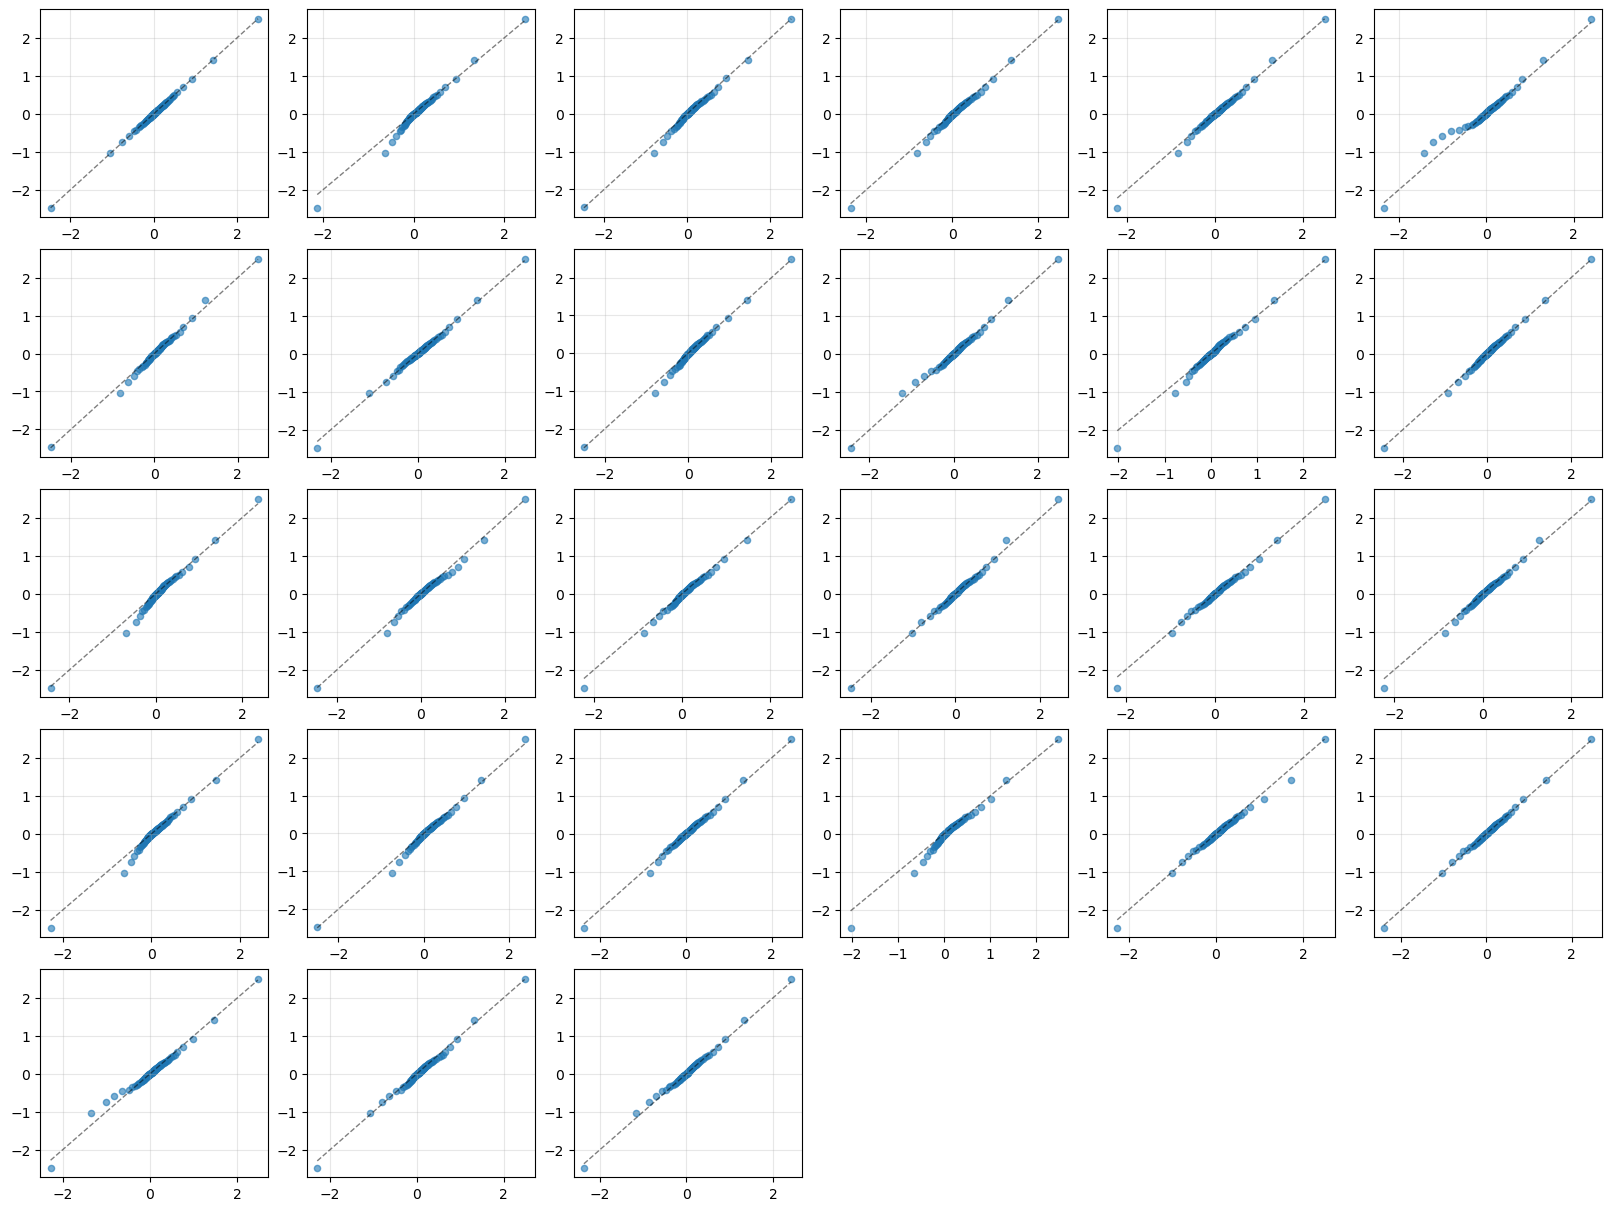

In [130]:
ncols = 6
nrows = 5

fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(16, 12), layout="constrained", dpi=100)
ax = axs.flatten()

# Reference quantiles from member 0
sref = slopes.sel(member=0).values
sref = sref[~np.isnan(sref)]
quantiles = np.linspace(0, 1, 100)
ref_quantiles = np.quantile(sref, quantiles)

for i, member in enumerate(slopes.member.values):
    s = slopes.sel(member=member).values
    s = s[~np.isnan(s)]
    member_quantiles = np.quantile(s, quantiles)
    
    ax[i].scatter(member_quantiles, ref_quantiles, s=20, alpha=0.6)
    ax[i].plot([member_quantiles.min(), member_quantiles.max()], 
               [member_quantiles.min(), member_quantiles.max()], 
               'k--', lw=1, alpha=0.5)
    # ax[i].set_xlabel(f'{xclim.ppe.get_member_name(member)}')
    # ax[i].set_ylabel('Member 0')
    ax[i].grid(alpha=0.3)

# Remove empty subplots
for i in range(len(slopes.member), ncols * nrows):
    ax[i].remove()

plt.show()

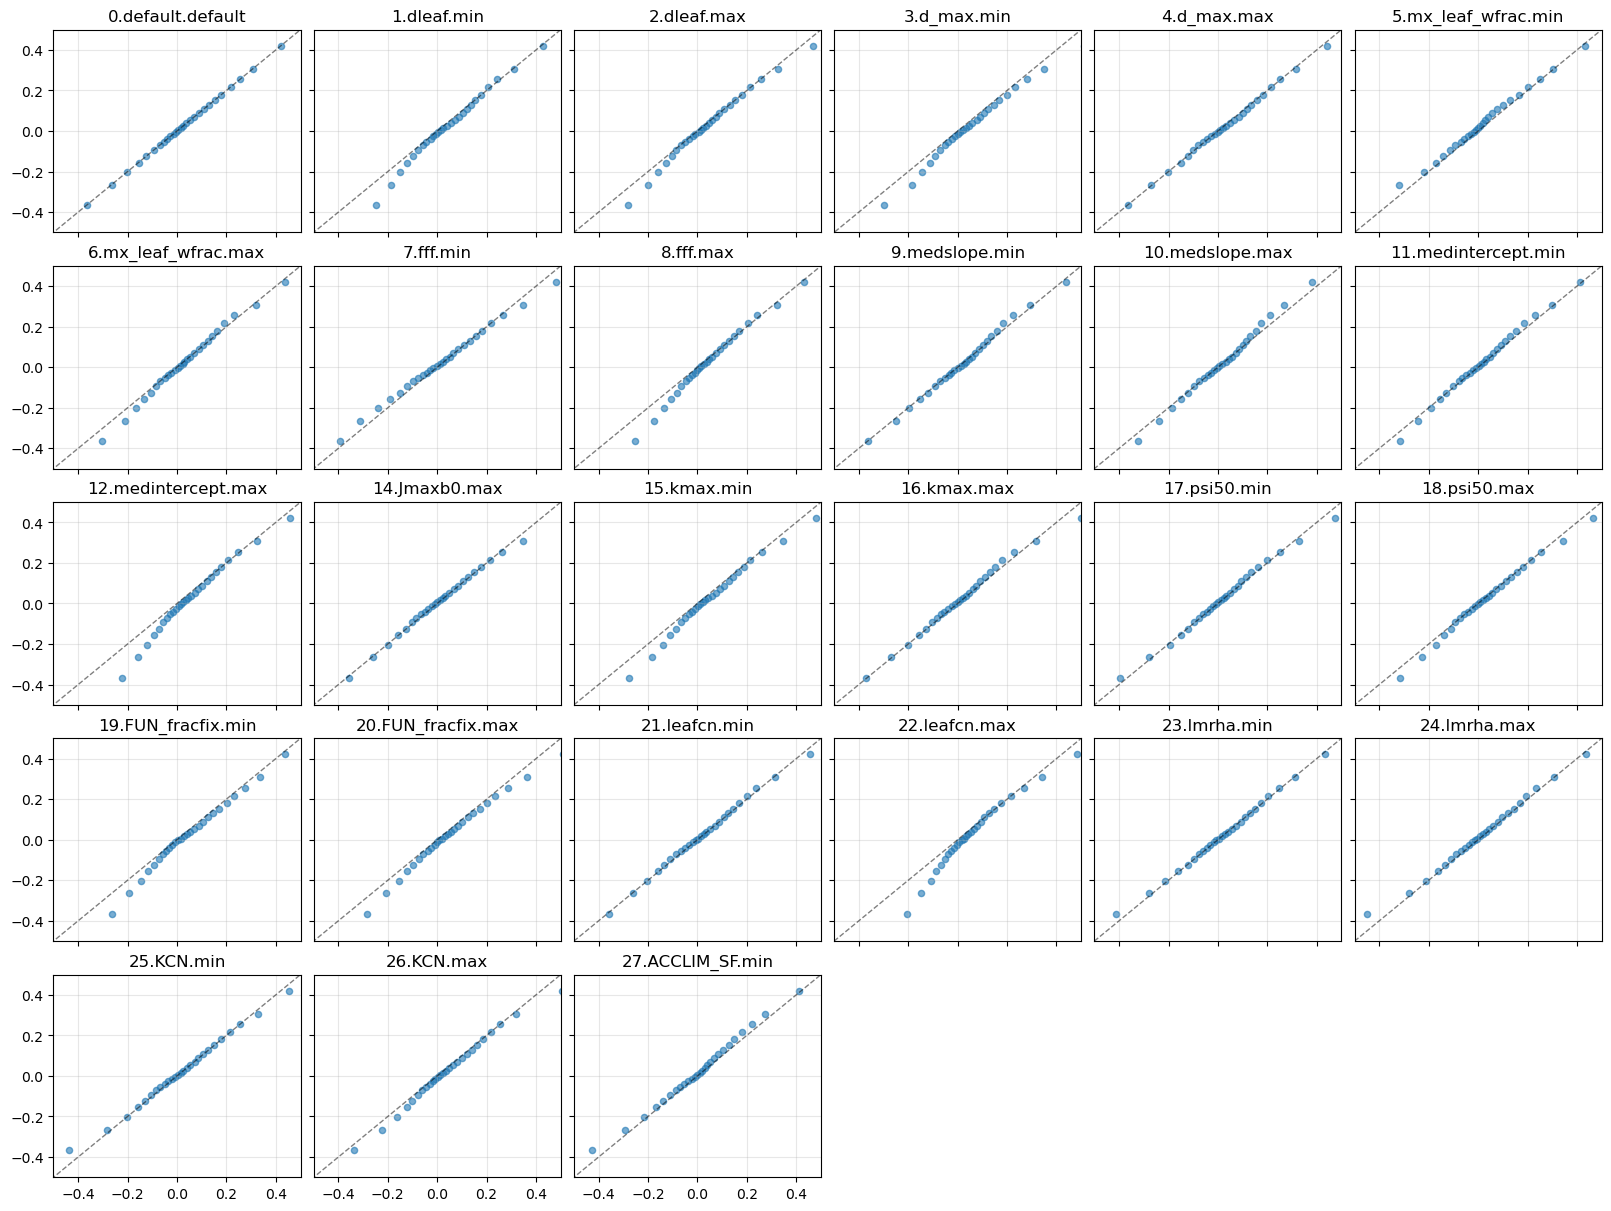

In [135]:
ncols = 6
nrows = 5

fig, axs = plt.subplots(ncols=ncols, nrows=nrows, sharex=True, sharey=True, figsize=(16, 12), layout="constrained", dpi=100)
ax = axs.flatten()

quantiles = np.linspace(0, 1, 30)

# Reference weighted quantiles from member 0
sref = slopes.sel(member=0).values
wref = area_fraction.values
sref_valid = sref[~np.isnan(sref)]
wref_valid = wref[~np.isnan(sref)]

s_sorted = np.sort(sref_valid)
w_sorted = wref_valid[np.argsort(sref_valid)]
w_cumsum = np.cumsum(w_sorted)
w_cumsum = w_cumsum / w_cumsum[-1]  # normalize to [0, 1]
# ref_quantiles = np.quantile(sref_valid, quantiles)
ref_quantiles = np.interp(quantiles, w_cumsum, s_sorted)

for i, member in enumerate(slopes.member.values):
    s = slopes.sel(member=member).values
    w = area_fraction.values
    s_valid = s[~np.isnan(s)]
    w_valid = w[~np.isnan(s)]
    
    # Weighted quantiles
    s_sorted = np.sort(s_valid)
    w_sorted = w_valid[np.argsort(s_valid)]
    w_cumsum = np.cumsum(w_sorted)
    w_cumsum = w_cumsum / w_cumsum[-1]  # normalize to [0, 1]
    member_quantiles = np.interp(quantiles, w_cumsum, s_sorted)
    
    ax[i].scatter(member_quantiles, ref_quantiles, s=20, alpha=0.6)
    ax[i].plot([member_quantiles.min(), member_quantiles.max()], 
               [member_quantiles.min(), member_quantiles.max()], 
               'k--', lw=1, alpha=0.5)
    ax[i].grid(alpha=0.3)
    ax[i].set_title(xclim.ppe.get_member_name(member))

    ax[i].set_xlim(-0.5, 0.5)
    ax[i].set_ylim(-0.5, 0.5)

# Remove empty subplots
for i in range(len(slopes.member), ncols * nrows):
    ax[i].remove()

plt.show()

Text(0.49999999999999994, -0.06, 'false discovery rate controlled at $\\alpha = 0.05$')

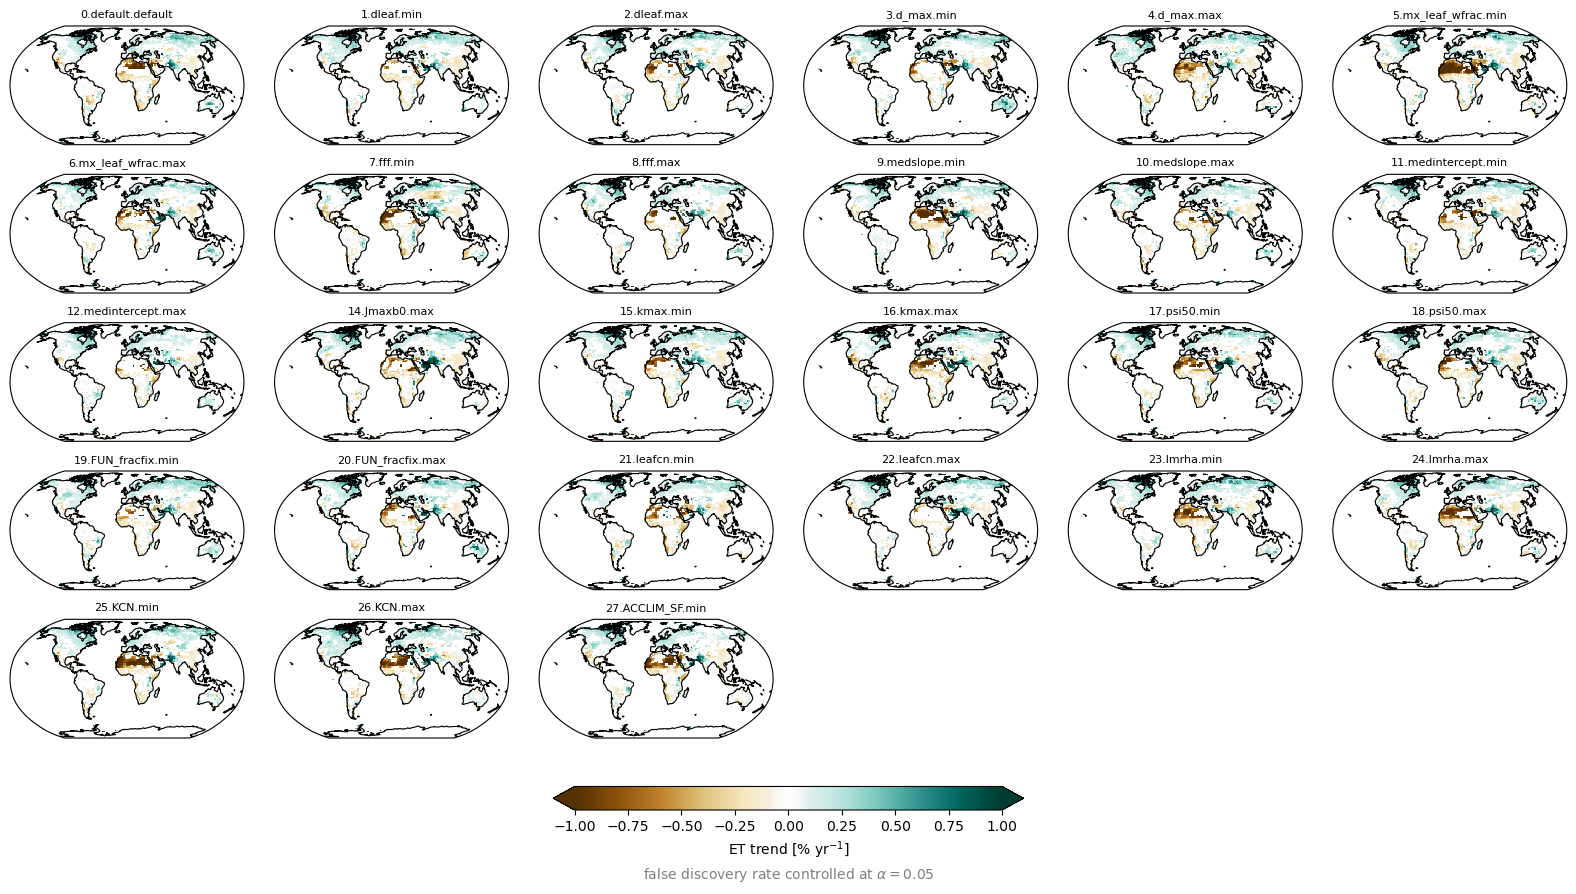

In [83]:
fg = xclim.plot.facetgrid_map.plot_facetgrid_map(
    da=et_dsc_pct_per_yr_masked.where(grid.PCT_GLC <= 80),
    dim='member',
    label='ET trend [% yr$^{-1}$]',
    parse_name=xclim.ppe.get_member_name,
    cmap=cmap,
    show_outer_labels=True,
    robust=True,
    vmin=-1,
    vmax=1,
)


fg.fig.canvas.draw()
cbar_pos = fg.cbar.ax.get_position()

fg.fig.text(
    (cbar_pos.x0 + cbar_pos.x1) / 2,
    cbar_pos.y0 - 0.07,
    f"false discovery rate controlled at $\\alpha = 0.05$",
    ha="center",
    va="top",
    fontsize=10,
    transform=fg.fig.transFigure,
    color='gray',
)

Text(0.49999999999999994, -0.06, 'false discovery rate controlled at $\\alpha = 0.05$')

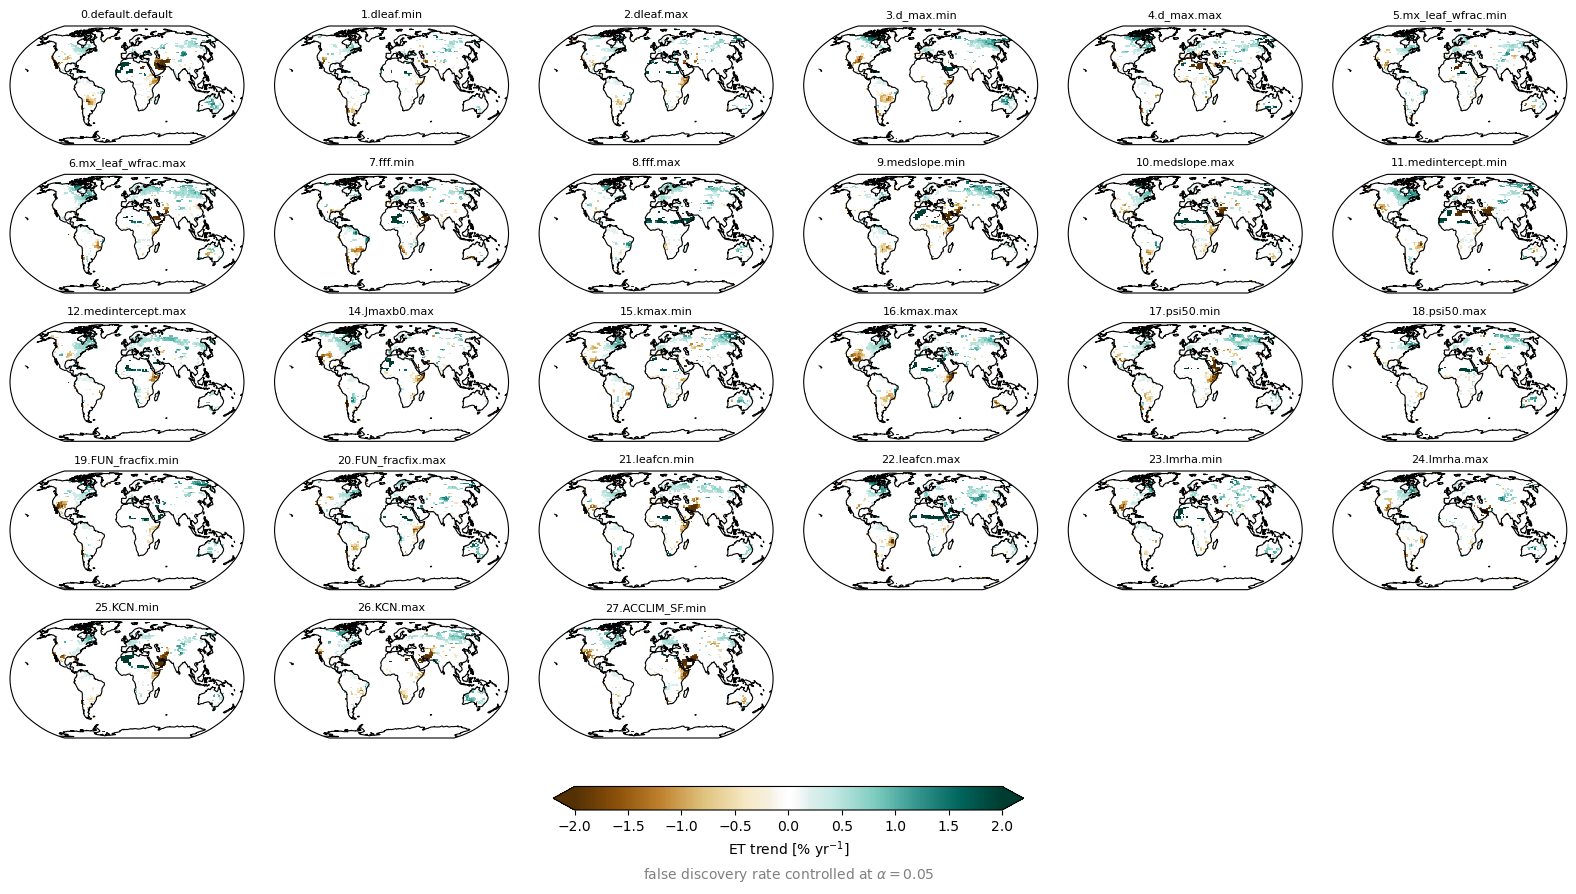

In [181]:
fg = xclim.plot.facetgrid_map.plot_facetgrid_map(
    da=et_dsc_1990_pct_per_yr_masked.where(grid.PCT_GLC <= 80),
    dim='member',
    label='ET trend [% yr$^{-1}$]',
    parse_name=xclim.ppe.get_member_name,
    cmap=cmap,
    show_outer_labels=True,
    robust=True,
    vmin=-2,
    vmax=2,
)


fg.fig.canvas.draw()
cbar_pos = fg.cbar.ax.get_position()

fg.fig.text(
    (cbar_pos.x0 + cbar_pos.x1) / 2,
    cbar_pos.y0 - 0.07,
    f"false discovery rate controlled at $\\alpha = 0.05$",
    ha="center",
    va="top",
    fontsize=10,
    transform=fg.fig.transFigure,
    color='gray',
)

In [16]:
0.2 / 1000 / 2.5e6 * 1000 * 86400 * 365

2.52288

In [17]:
1000 * 2.5e6 / 1000 / 86400 / 365

0.07927447995941148

Text(0.49999999999999994, -0.06, 'false discovery rate controlled at $\\alpha = 0.05$')

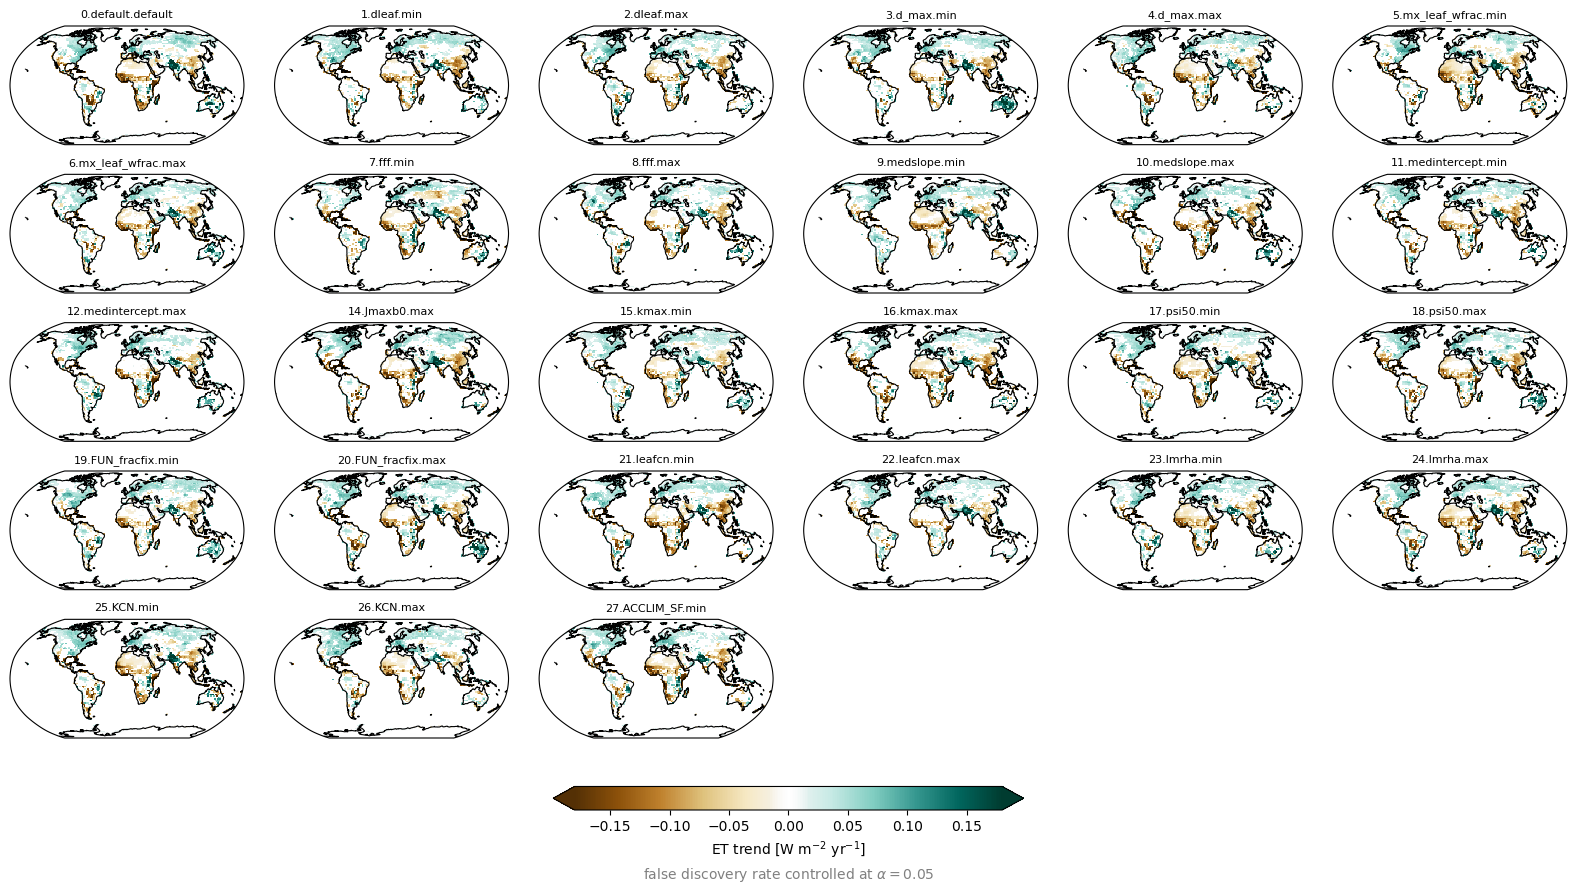

In [ ]:
plt.rcdefaults()
fg = xclim.plot.facetgrid_map.plot_facetgrid_map(
    da=et_dsc_ols.slope_fdr_masked,
    # da=et_dsc_ols.slope_fdr_masked / 1000 / 2.5e6 * 1000 * 86400 * 365,
    dim='member',
    label='ET trend [W m$^{-2}$ yr$^{-1}$]',
    # label='ET trend [mm yr$^{-1}$]',
    parse_name=xclim.ppe.get_member_name,
    cmap=cmap,
    show_outer_labels=True,
    robust=True,
    # vmin=-0.2,
    # vmax=0.2,
    # vmin=-2 / 1000 / 2.5e6 * 1000 * 86400 * 365,
    # vmax=2 / 1000 / 2.5e6 * 1000 * 86400 * 365,
)


fg.fig.canvas.draw()
cbar_pos = fg.cbar.ax.get_position()

fg.fig.text(
    (cbar_pos.x0 + cbar_pos.x1) / 2,
    cbar_pos.y0 - 0.07,
    f"false discovery rate controlled at $\\alpha = 0.05$",
    ha="center",
    va="top",
    fontsize=10,
    transform=fg.fig.transFigure,
    color='gray',
)

# fg.fig.savefig('fig/lmwg/trend.dsc.map.lnd.ET.mmyr.png', dpi=300, bbox_inches='tight')

In [174]:
1 / 1000 / 2.5e6 * 1000 * 86400 * 365

12.6144

Text(0.49999999999999994, -0.06, 'false discovery rate controlled at $\\alpha = 0.05$')

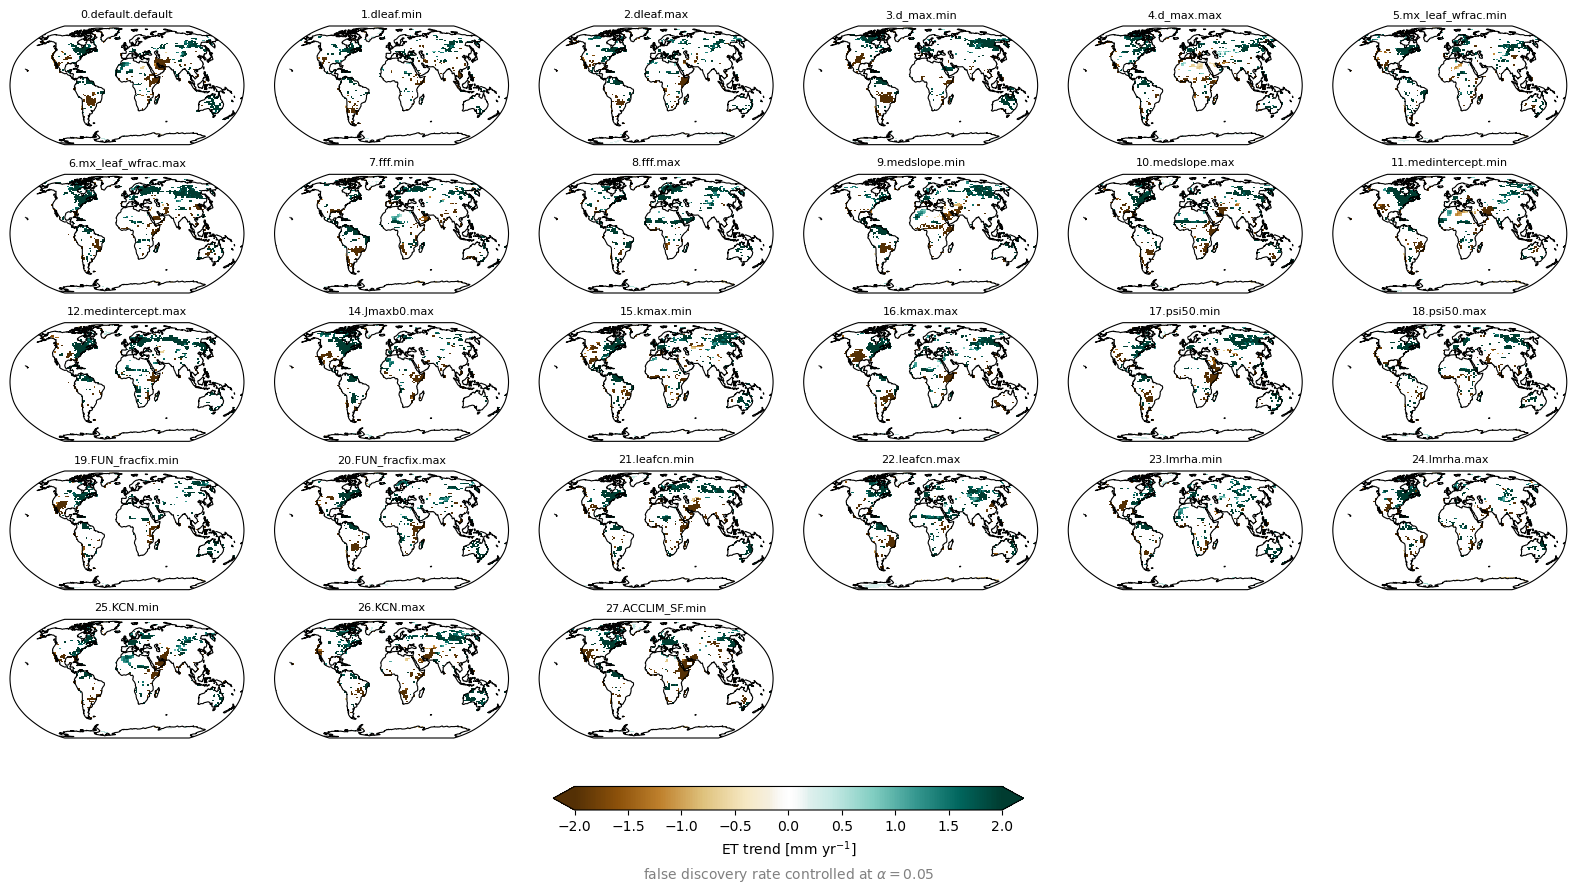

In [ ]:
plt.rcdefaults()
fg = xclim.plot.facetgrid_map.plot_facetgrid_map(
    # da=et_dsc_ols.slope_fdr_masked,
    da=et_dsc_1990_ols.slope_fdr_masked / 1000 / 2.5e6 * 1000 * 86400 * 365,
    dim='member',
    # label='ET trend [W m$^{-2}$ yr$^{-1}$]',
    label='ET trend [mm yr$^{-1}$]',
    parse_name=xclim.ppe.get_member_name,
    cmap=cmap,
    show_outer_labels=True,
    robust=True,
    # vmin=-0.2,
    # vmax=0.2,
    vmin=-6,
    vmax=6,
)


fg.fig.canvas.draw()
cbar_pos = fg.cbar.ax.get_position()

fg.fig.text(
    (cbar_pos.x0 + cbar_pos.x1) / 2,
    cbar_pos.y0 - 0.07,
    f"false discovery rate controlled at $\\alpha = 0.05$",
    ha="center",
    va="top",
    fontsize=10,
    transform=fg.fig.transFigure,
    color='gray',
)

# fg.fig.savefig('fig/lmwg/trend1990.dsc.map.lnd.ET.mmyr.png', dpi=300, bbox_inches='tight')

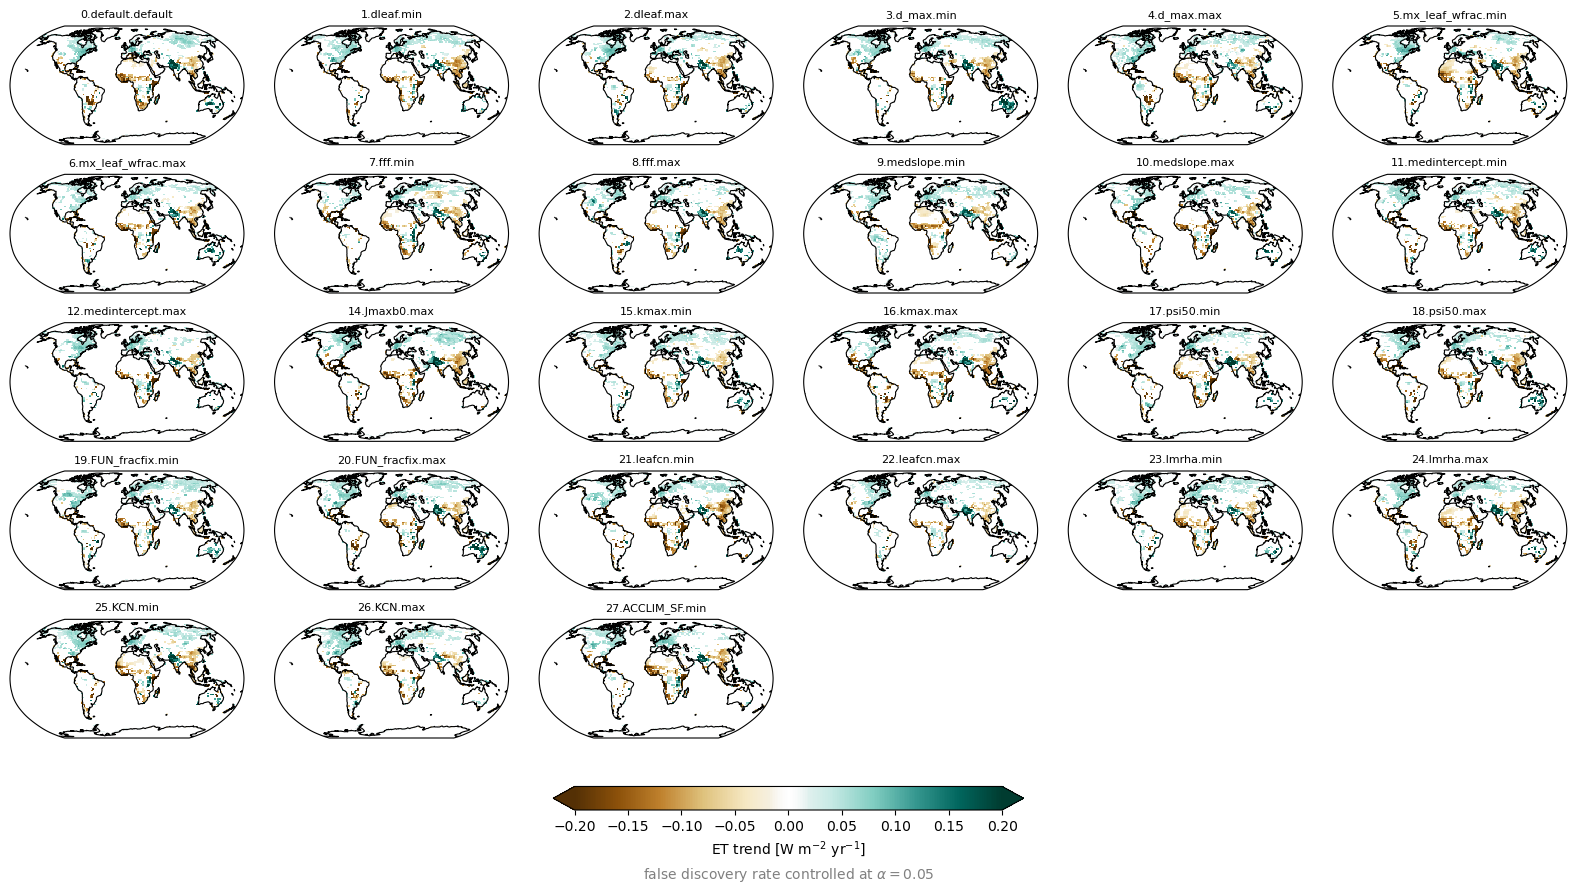

In [61]:
fg = xclim.plot.facetgrid_map.plot_facetgrid_map(
    da=et_yr_ols.slope_fdr_masked,
    dim='member',
    label='ET trend [W m$^{-2}$ yr$^{-1}$]',
    parse_name=xclim.ppe.get_member_name,
    cmap=cmap,
    show_outer_labels=True,
    robust=True,
    vmin=-0.2,
    vmax=0.2,
)


fg.fig.canvas.draw()
cbar_pos = fg.cbar.ax.get_position()

fg.fig.text(
    (cbar_pos.x0 + cbar_pos.x1) / 2,
    cbar_pos.y0 - 0.07,
    f"false discovery rate controlled at $\\alpha = 0.05$",
    ha="center",
    va="top",
    fontsize=10,
    transform=fg.fig.transFigure,
    color='gray',
)

fg.fig.savefig('fig/lmwg/trend.yr.map.lnd.ET.png', dpi=300, bbox_inches='tight')

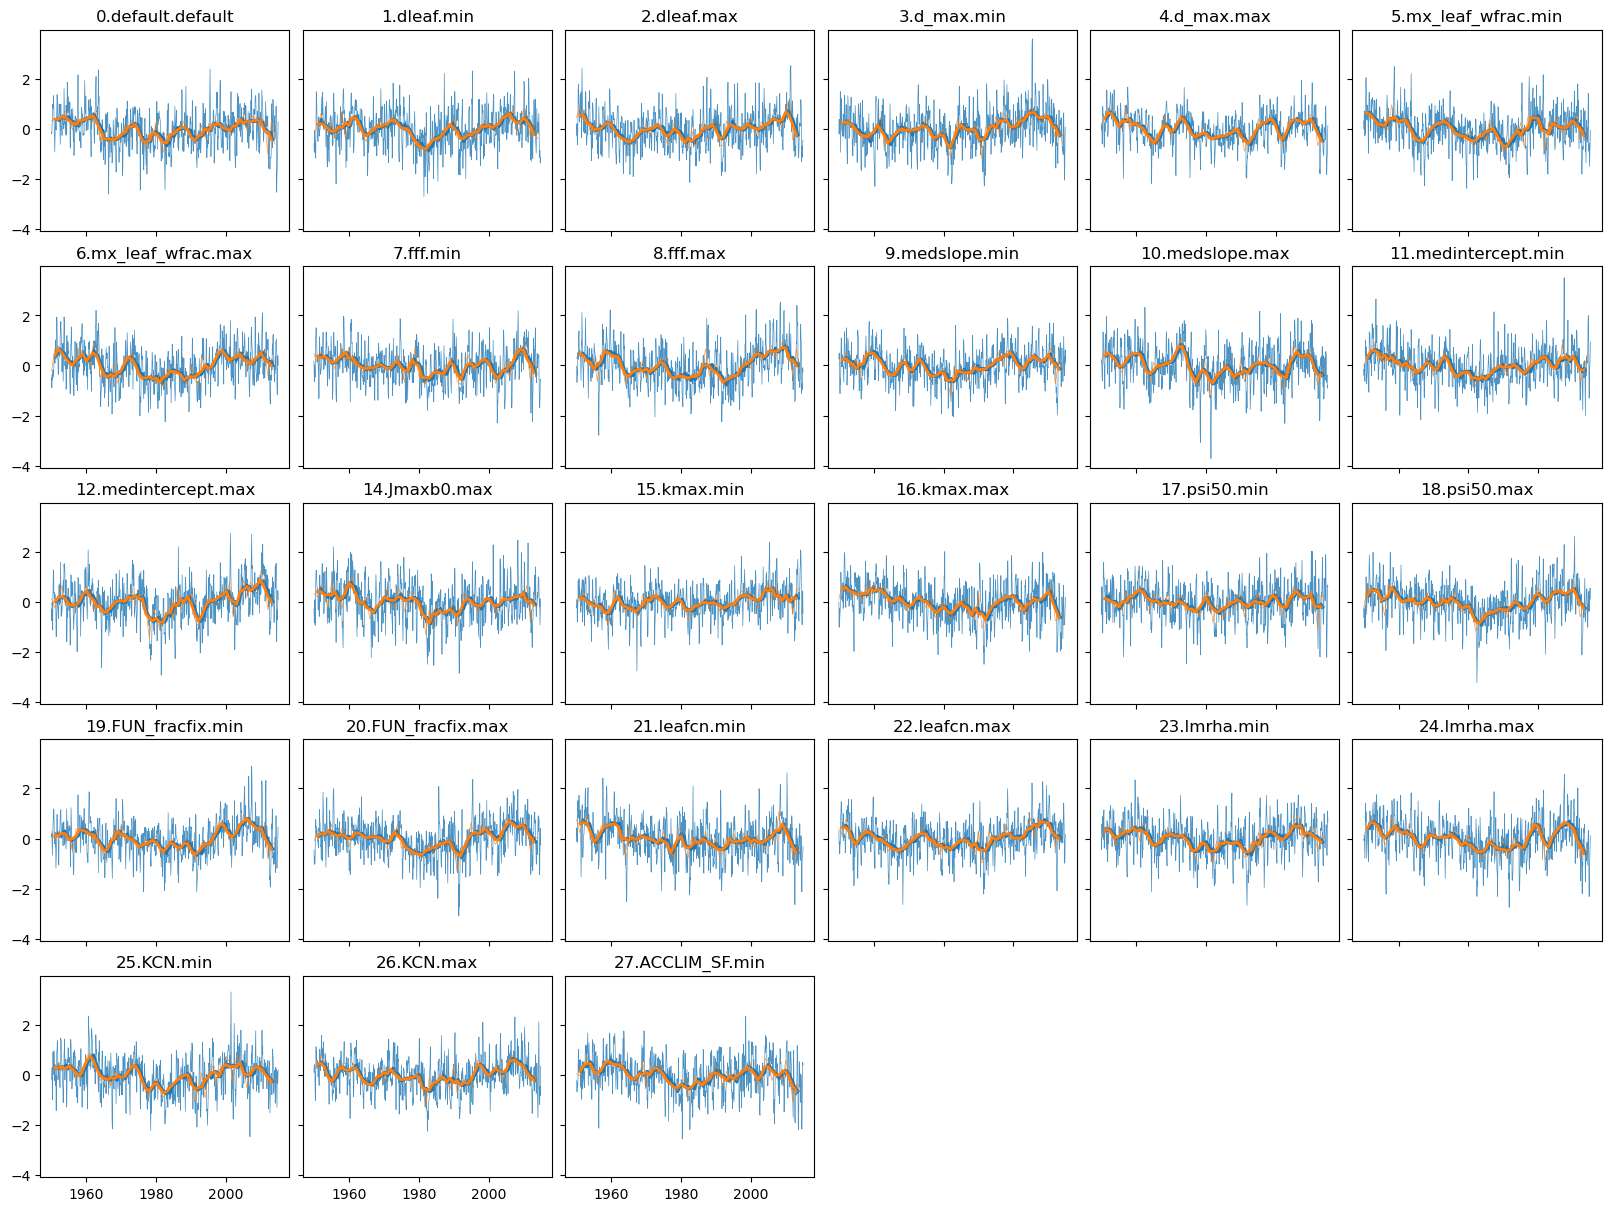

In [46]:
ncols = 6
nrows = 5

fig, axs = plt.subplots(ncols=ncols, nrows=nrows, sharex=True, sharey=True, figsize=(16, 12), layout="constrained", dpi=100)
ax = axs.flatten()

for i, m in enumerate(et_gm_dsc.member.values):

    et_gm_dsc.sel(member=m).plot(ax=ax[i], c='tab:blue', lw=0.5, alpha=0.8)
    et_gm_dsc.sel(member=m).rolling(time=36, center=True).mean().plot(ax=ax[i], c='tab:blue', lw=2, alpha=1)

    et_gm_yr.sel(member=m).plot(ax=ax[i], c='tab:orange', lw=0.5, alpha=0.8)
    et_gm_yr.sel(member=m).rolling(year=3, center=True).mean().plot(ax=ax[i], c='tab:orange', lw=2, alpha=1)

    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_title(xclim.ppe.get_member_name(m))

for i in range(len(et_gm_dsc.member), ncols * nrows):
    ax[i].remove()

Text(0.5, 1.0, '0.default.default')

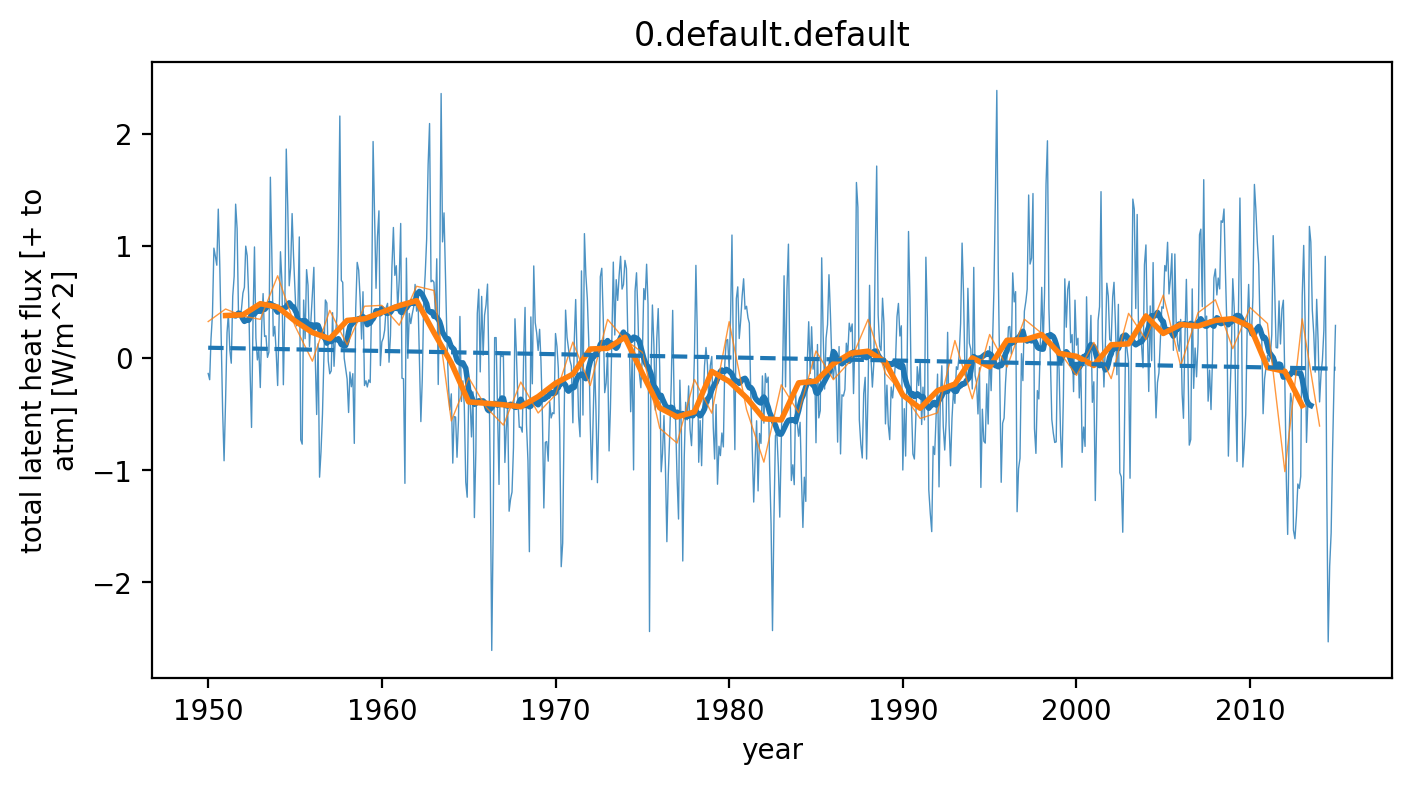

In [41]:
m = 0

plt.figure(figsize=(8, 4), dpi=200)

et_gm_dsc.sel(member=m).plot(c='tab:blue', lw=0.5, alpha=0.8)
et_gm_dsc.sel(member=m).rolling(time=36, center=True).mean().plot(c='tab:blue', lw=2, alpha=1)

et_gm_yr.sel(member=m).plot(c='tab:orange', lw=0.5, alpha=0.8)
et_gm_yr.sel(member=m).rolling(year=3, center=True).mean().plot(c='tab:orange', lw=2, alpha=1)

plt.plot(et_gm_dsc.time, et_gm_dsc_ols.sel(member=m).slope.item() * et_gm_dsc.time + et_gm_dsc_ols.sel(member=m).intercept.item(), ls='--')

plt.title(xclim.ppe.get_member_name(m))

# LENS2

In [26]:
## CESM2 LE

variables_lens = [
    "EFLX_LH_TOT",
    # "TLAI",
]

grid_lens = xclim.load_cesm2le_grid()
nonglc_mask_lens = grid_lens.PCT_GLC <= nonglc_pct_threshold

lens = {}
for v in variables_lens:
    print(f"  {v}")
    vv = f"{v}_month_1"
    lens[vv] = xclim.load_cesm2le(v, "lnd", "month_1", "h0", keep_var_only=True).sel(time=time_slice)[v].reindex_like(grid_lens, method="nearest", tolerance=1e-3)
    lens[vv] = lens[vv].where(nonglc_mask_lens).chunk({'time': -1, 'lat': -1, 'lon': -1})
    lens[vv].attrs["masks"] = f"gridcell percent glaciated land <= {nonglc_pct_threshold}"

    lens[vv] = lens[vv].chunk({'time': -1})

  EFLX_LH_TOT


In [27]:
et_gm_ts_lens = lens['EFLX_LH_TOT_month_1'].weighted(grid_lens.LANDAREA).mean(dim=['lat', 'lon'])

et_gm_sc_lens = et_gm_ts_lens.groupby('time.month').mean()
et_gm_dsc_lens = et_gm_ts_lens.groupby('time.month') - et_gm_sc_lens

et_gm_ta_lens = et_gm_ts_lens.mean(dim='time')
et_gm_yr_lens = et_gm_ts_lens.groupby('time.year').mean() - et_gm_ta_lens

et_gm_dsc_lens['time'] = et_gm_dsc_lens.time.dt.year + (et_gm_dsc_lens.time.dt.dayofyear - 1) / 365.25

et_gm_yr_lens = et_gm_yr_lens.chunk({'year': -1})
et_gm_dsc_lens = et_gm_dsc_lens.chunk({'time': -1})

In [28]:
et_gm_dsc_lens_ols = xclim.regression.ols_field(et_gm_dsc_lens.time, et_gm_dsc_lens, sample_dim='time', alpha=0.05).compute()
et_gm_yr_lens_ols = xclim.regression.ols_field(et_gm_yr_lens.year, et_gm_yr_lens, sample_dim='year', alpha=0.05).compute()

In [29]:
et_gm_dsc_lens_1990_ols = xclim.regression.ols_field(et_gm_dsc_lens.time.sel(time=slice('1990-01', None)), et_gm_dsc_lens.sel(time=slice('1990-01', None)), sample_dim='time', alpha=0.05).compute()
et_gm_yr_lens_1990_ols = xclim.regression.ols_field(et_gm_yr_lens.year.sel(year=slice(1990, None)), et_gm_yr_lens.sel(year=slice(1990, None)), sample_dim='year', alpha=0.05).compute()

# GOGA2

In [30]:
## GOGA2

variables_goga = [
    "EFLX_LH_TOT",
    # "TLAI",
]

grid_goga = xclim.load_goga2_grid()
nonglc_mask_goga = grid_lens.PCT_GLC <= nonglc_pct_threshold

goga = {}
for v in variables_goga:
    print(f"  {v}")
    vv = f"{v}_month_1"
    goga[vv] = xclim.load_goga2(v, "lnd", "month_1", "h0", keep_var_only=True).sel(time=time_slice)[v].reindex_like(grid_goga, method="nearest", tolerance=1e-3)
    goga[vv] = goga[vv].where(nonglc_mask_goga).chunk({'time': -1, 'lat': -1, 'lon': -1})
    goga[vv].attrs["masks"] = f"gridcell percent glaciated land <= {nonglc_pct_threshold}"

    goga[vv] = goga[vv].chunk({'time': -1})

  EFLX_LH_TOT


In [31]:
et_gm_ts_goga = goga['EFLX_LH_TOT_month_1'].weighted(grid_goga.LANDAREA).mean(dim=['lat', 'lon'])

et_gm_sc_goga = et_gm_ts_goga.groupby('time.month').mean()
et_gm_dsc_goga = et_gm_ts_goga.groupby('time.month') - et_gm_sc_goga

et_gm_ta_goga = et_gm_ts_goga.mean(dim='time')
et_gm_yr_goga = et_gm_ts_goga.groupby('time.year').mean() - et_gm_ta_goga

et_gm_dsc_goga['time'] = et_gm_dsc_goga.time.dt.year + (et_gm_dsc_goga.time.dt.dayofyear - 1) / 365.25

et_gm_yr_goga = et_gm_yr_goga.chunk({'year': -1})
et_gm_dsc_goga = et_gm_dsc_goga.chunk({'time': -1})

In [32]:
et_gm_dsc_goga_ols = xclim.regression.ols_field(et_gm_dsc_goga.time, et_gm_dsc_goga, sample_dim='time', alpha=0.05).compute()
et_gm_yr_goga_ols = xclim.regression.ols_field(et_gm_yr_goga.year, et_gm_yr_goga, sample_dim='year', alpha=0.05).compute()

no p-values above the FDR control level


In [33]:
et_gm_dsc_goga_1990_ols = xclim.regression.ols_field(et_gm_dsc_goga.time.sel(time=slice('1990-01', None)), et_gm_dsc_goga.sel(time=slice('1990-01', None)), sample_dim='time', alpha=0.05).compute()
et_gm_yr_goga_1990_ols = xclim.regression.ols_field(et_gm_yr_goga.year.sel(year=slice(1990, None)), et_gm_yr_goga.sel(year=slice(1990, None)), sample_dim='year', alpha=0.05).compute()

no p-values above the FDR control level


# trend histograms

## individual

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
# (et_gm_dsc_goga_ols.slope.where(et_gm_dsc_goga_ols.slope_p_value < 0.01) * 100).plot.hist(ax=ax, bins=np.linspace(-4, 4, 15), color='#009A90', hatch='none', edgecolor='none', alpha=0.5, label='1950-2014')
# (et_gm_dsc_goga_1990_ols.slope.where(et_gm_dsc_goga_1990_ols.slope_p_value < 0.01) * 100).plot.hist(ax=ax, bins=np.linspace(-4, 4, 15), color='#001563', hatch='none', edgecolor='none', alpha=0.5, label='1990-2014')
(et_gm_dsc_goga_ols.slope.where(et_gm_dsc_goga_ols.slope_p_value < 0.01) * 100).plot.hist(ax=ax, bins=np.linspace(-4, 4, 15), color='indianred', hatch='..', edgecolor='white', alpha=0.5, label='1950-2014')
(et_gm_dsc_goga_1990_ols.slope.where(et_gm_dsc_goga_1990_ols.slope_p_value < 0.01) * 100).plot.hist(ax=ax, bins=np.linspace(-4, 4, 15), color='indianred', hatch='//', edgecolor='white', alpha=0.5, label='1990-2014')
ax.set_yticks([0, 2, 4, 6, 8, 10, 12])
ax.set_xlabel('[$\\times 10^{-2}$ W m$^{-2}$ yr$^{-1}$]')
ax.set_ylabel('# of members')
ax.legend(fontsize=12, title='Trend period', title_fontproperties={'size': 14}, frameon=False, loc='upper left')
xclim.plot.center_axis_at_zero(ax, 'x')

secax = ax.secondary_xaxis('top', functions=(lambda x: x / 100 / 1000 / 2.5e6 * 1000 * 86400 * 365, lambda x: x * 100 * 1000 * 2.5e6 / 1000 / 86400 / 365))
secax.set_xlabel('[mm yr$^{-1}$]', labelpad=8)

# fig.savefig('fig/lmwg/trend.dsc.hist.lnd.ET.GOGA2.png', dpi=300, bbox_inches='tight')

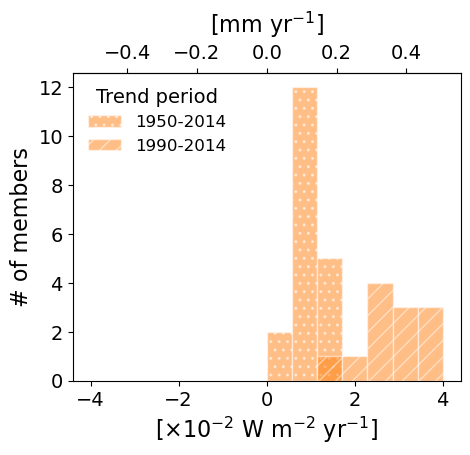

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
# (et_gm_dsc_lens_ols.slope.where(et_gm_dsc_lens_ols.slope_p_value < 0.01) * 100).plot.hist(ax=ax, bins=np.linspace(-4, 4, 15), color='#009A90', hatch='none', edgecolor='none', alpha=0.5, label='1950-2014')
# (et_gm_dsc_lens_1990_ols.slope.where(et_gm_dsc_lens_1990_ols.slope_p_value < 0.01) * 100).plot.hist(ax=ax, bins=np.linspace(-4, 4, 15), color='#001563', hatch='none', edgecolor='none', alpha=0.5, label='1990-2014')
(et_gm_dsc_lens_ols.slope.where(et_gm_dsc_lens_ols.slope_p_value < 0.01) * 100).plot.hist(ax=ax, bins=np.linspace(-4, 4, 15), color='tab:orange', hatch='..', edgecolor='white', alpha=0.5, label='1950-2014')
(et_gm_dsc_lens_1990_ols.slope.where(et_gm_dsc_lens_1990_ols.slope_p_value < 0.01) * 100).plot.hist(ax=ax, bins=np.linspace(-4, 4, 15), color='tab:orange', hatch='//', edgecolor='white', alpha=0.5, label='1990-2014')
ax.set_yticks([0, 2, 4, 6, 8, 10, 12])
ax.set_xlabel('[$\\times 10^{-2}$ W m$^{-2}$ yr$^{-1}$]')
ax.set_ylabel('# of members')
ax.legend(fontsize=12, title='Trend period', title_fontproperties={'size': 14}, frameon=False, loc='upper left')
xclim.plot.center_axis_at_zero(ax, 'x')

secax = ax.secondary_xaxis('top', functions=(lambda x: x / 100 / 1000 / 2.5e6 * 1000 * 86400 * 365, lambda x: x * 100 * 1000 * 2.5e6 / 1000 / 86400 / 365))
secax.set_xlabel('[mm yr$^{-1}$]', labelpad=8)

# fig.savefig('fig/lmwg/trend.dsc.hist.lnd.ET.LENS2.png', dpi=300, bbox_inches='tight')

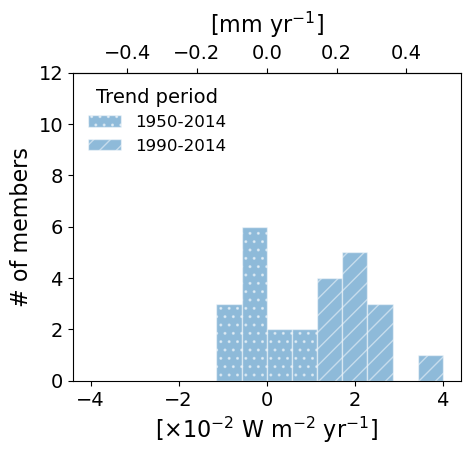

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
# (et_gm_dsc_ols.slope.where(et_gm_dsc_ols.slope_p_value < 0.01) * 100).plot.hist(ax=ax, bins=np.linspace(-4, 4, 15), color='#009A90', hatch='none', edgecolor='none', alpha=0.5, label='1950-2014')
# (et_gm_dsc_1990_ols.slope.where(et_gm_dsc_1990_ols.slope_p_value < 0.01) * 100).plot.hist(ax=ax, bins=np.linspace(-4, 4, 15), color='#001563', hatch='none', edgecolor='none', alpha=0.5, label='1990-2014')
(et_gm_dsc_ols.slope.where(et_gm_dsc_ols.slope_p_value < 0.01) * 100).plot.hist(ax=ax, bins=np.linspace(-4, 4, 15), color='tab:blue', hatch='..', edgecolor='white', alpha=0.5, label='1950-2014')
(et_gm_dsc_1990_ols.slope.where(et_gm_dsc_1990_ols.slope_p_value < 0.01) * 100).plot.hist(ax=ax, bins=np.linspace(-4, 4, 15), color='tab:blue', hatch='//', edgecolor='white', alpha=0.5, label='1990-2014')
ax.set_yticks([0, 2, 4, 6, 8, 10, 12])
ax.set_xlabel('[$\\times 10^{-2}$ W m$^{-2}$ yr$^{-1}$]')
ax.set_ylabel('# of members')
ax.legend(fontsize=12, title='Trend period', title_fontproperties={'size': 14}, frameon=False, loc='upper left')
xclim.plot.center_axis_at_zero(ax, 'x')

secax = ax.secondary_xaxis('top', functions=(lambda x: x / 100 / 1000 / 2.5e6 * 1000 * 86400 * 365, lambda x: x * 100 * 1000 * 2.5e6 / 1000 / 86400 / 365))
secax.set_xlabel('[mm yr$^{-1}$]', labelpad=8)

# fig.savefig('fig/lmwg/trend.dsc.hist.lnd.ET.FHIST.png', dpi=300, bbox_inches='tight')

## combined

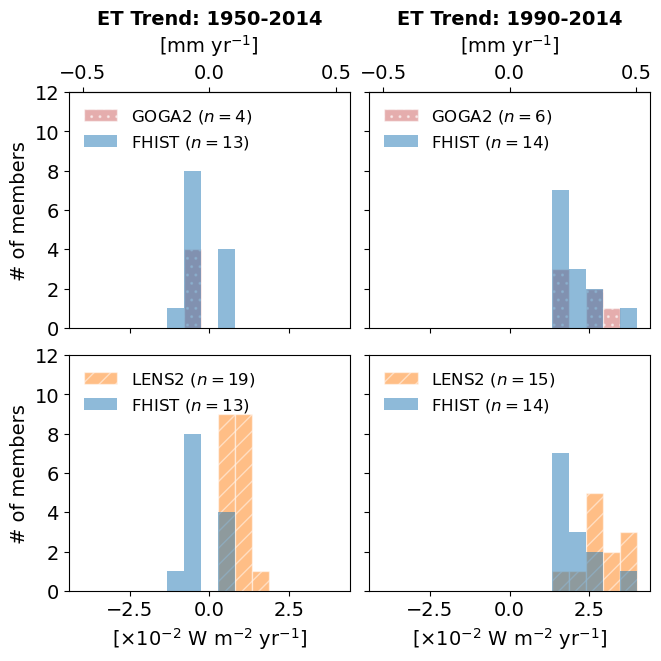

In [69]:
fig, axs = plt.subplots(2, 2, sharey=True, sharex=True, figsize=(6.5, 6.5), layout='constrained')
ax = axs.flatten()
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14

nbin = 16
alpha = 0.01

(et_gm_dsc_goga_ols.slope.where(et_gm_dsc_goga_ols.slope_p_value < alpha) * 100).plot.hist(ax=ax[0], bins=np.linspace(-4, 4, nbin), color='indianred', alpha=0.5, hatch='..', edgecolor='white', label=f'GOGA2 $(n={(et_gm_dsc_goga_ols.slope_p_value < alpha).sum().values})$')
(et_gm_dsc_ols.slope.where(et_gm_dsc_ols.slope_p_value < alpha) * 100).plot.hist(ax=ax[0], bins=np.linspace(-4, 4, nbin), color='tab:blue', alpha=0.5, label=f'FHIST $(n={(et_gm_dsc_ols.slope_p_value < alpha).sum().values})$')

(et_gm_dsc_goga_1990_ols.slope.where(et_gm_dsc_goga_1990_ols.slope_p_value < alpha) * 100).plot.hist(ax=ax[1], bins=np.linspace(-4, 4, nbin), color='indianred', alpha=0.5, hatch='..', edgecolor='white', label=f'GOGA2 $(n={(et_gm_dsc_goga_1990_ols.slope_p_value < alpha).sum().values})$')
(et_gm_dsc_1990_ols.slope.where(et_gm_dsc_1990_ols.slope_p_value < alpha) * 100).plot.hist(ax=ax[1], bins=np.linspace(-4, 4, nbin), color='tab:blue', alpha=0.5, label=f'FHIST $(n={(et_gm_dsc_1990_ols.slope_p_value < alpha).sum().values})$')

(et_gm_dsc_lens_ols.slope.where(et_gm_dsc_lens_ols.slope_p_value < alpha) * 100).plot.hist(ax=ax[2], bins=np.linspace(-4, 4, nbin), color='tab:orange', alpha=0.5, hatch='//', edgecolor='white', label=f'LENS2 $(n={(et_gm_dsc_lens_ols.slope_p_value < alpha).sum().values})$')
(et_gm_dsc_ols.slope.where(et_gm_dsc_ols.slope_p_value < alpha) * 100).plot.hist(ax=ax[2], bins=np.linspace(-4, 4, nbin), color='tab:blue', alpha=0.5, label=f'FHIST $(n={(et_gm_dsc_ols.slope_p_value < alpha).sum().values})$')

(et_gm_dsc_lens_1990_ols.slope.where(et_gm_dsc_lens_1990_ols.slope_p_value < alpha) * 100).plot.hist(ax=ax[3], bins=np.linspace(-4, 4, nbin), color='tab:orange', alpha=0.5, hatch='//', edgecolor='white', label=f'LENS2 $(n={(et_gm_dsc_lens_1990_ols.slope_p_value < alpha).sum().values})$')
(et_gm_dsc_1990_ols.slope.where(et_gm_dsc_1990_ols.slope_p_value < alpha) * 100).plot.hist(ax=ax[3], bins=np.linspace(-4, 4, nbin), color='tab:blue', alpha=0.5, label=f'FHIST $(n={(et_gm_dsc_1990_ols.slope_p_value < alpha).sum().values})$')

for i in range(4):
    ax[i].set_xlabel('')
    ax[i].set_yticks([0, 2, 4, 6, 8, 10, 12])
    ax[i].legend(fontsize=12, frameon=False, loc='upper left')
    xclim.plot.center_axis_at_zero(ax[i], 'x')

    if i % 2 == 0:
        ax[i].set_ylabel('# of members')
    if i % 4 > 1:
        ax[i].set_xlabel('[$\\times 10^{-2}$ W m$^{-2}$ yr$^{-1}$]', fontsize=14)
    if i // 2 == 0:
        secax = ax[i].secondary_xaxis('top', functions=(lambda x: x / 100 / 1000 / 2.5e6 * 1000 * 86400 * 365, lambda x: x * 100 * 1000 * 2.5e6 / 1000 / 86400 / 365))
        secax.set_xlabel('[mm yr$^{-1}$]', labelpad=8)


ax[0].set_title('ET Trend: 1950-2014', fontsize=14, fontweight='bold', loc='center')
ax[1].set_title('ET Trend: 1990-2014', fontsize=14, fontweight='bold', loc='center')


fig.savefig('fig/trend.dsc.hist.lnd.ET.FHIST-LENS2-GOGA2.png', dpi=300, bbox_inches='tight')